# 24. 모델 학습 및 하이퍼파라미터 최적화 (README §6)

이 노트북은 README의 6장에 기술된 **UnderBagging Ensemble** 방식과 **단일 하이퍼파라미터 튜닝** 파이프라인을 실행합니다.

### 실행 단계
1. **데이터 준비**: Full Train (10 Subsets), Full Validation, Sampled Validation 로드
2. **[Optuna Tuning] 하이퍼파라미터 탐색**: 넓은 탐색 공간, 가지치기(Pruning) 활성화, `n_estimators` 포함
3. **[Reranking] 최종 파라미터 선정**: Sampled 검증셋의 편향 리스크를 줄이기 위해 상위 후보들을 Full Validation으로 재평가
4. **최종 모델 저장**: 산출된 최적 파라미터 및 앙상블 모델을 저장

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, json, shutil, uuid
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

sys.path.insert(0, os.path.abspath('..'))  # for execution from notebooks/

import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, confusion_matrix

import config.train_config as cfg

print('Environment ready')
print(f'TRAIN_PATH    : {cfg.TRAIN_PATH}')
print(f'VAL_TUNE_PATH : {cfg.VAL_TUNE_PATH}')
print(f'VAL_SAMPLED   : {cfg.VAL_TUNE_SAMPLED_PATH}')


c:\Workspace\06_ML_projdect\26_1_COIN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready
TRAIN_PATH    : C:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\train.parquet
VAL_TUNE_PATH : C:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\val_tune.parquet
VAL_SAMPLED   : C:\Workspace\06_ML_projdect\26_1_COIN\data2\06_subset_generation\seed_42\val_sampled.parquet


## 1. 데이터 준비

In [2]:
def remove_failure_day_rows(df: pd.DataFrame, *, target_col: str = 'failure', name: str = 'val_tune') -> pd.DataFrame:
    """Remove D-day and post-failure rows from tune validation data."""
    before = len(df)
    out = df.copy()
    remove_mask = pd.Series(False, index=out.index)
    rules = []

    if 'days_to_failure' in out.columns:
        dtf = pd.to_numeric(out['days_to_failure'], errors='coerce')
        mask = dtf.le(0)
        remove_mask |= mask.fillna(False)
        rules.append('days_to_failure <= 0')

    if {'date', 'failure_date'}.issubset(out.columns):
        mask = pd.to_datetime(out['date']).ge(pd.to_datetime(out['failure_date']))
        remove_mask |= mask.fillna(False)
        rules.append('date >= failure_date')

    if target_col in out.columns:
        mask = out[target_col].eq(1)
        remove_mask |= mask.fillna(False)
        rules.append(f'{target_col} == 1')

    out = out.loc[~remove_mask].reset_index(drop=True)
    rule_text = ' OR '.join(rules) if rules else 'no matching D-day/post-failure rule'
    print(f'{name}: removed {int(remove_mask.sum()):,} D-day/post-failure rows by [{rule_text}] ({before:,} -> {len(out):,})')
    return out


def sanitize_feature_cols(feature_cols: list[str], df: pd.DataFrame, *, target_col: str) -> list[str]:
    blocked = {'serial_number', 'date', 'failure', 'failure_date', 'days_to_failure', target_col}
    if feature_cols is None:
        return [c for c in df.columns if c not in blocked]
    return [c for c in feature_cols if c not in blocked]


df_train    = pd.read_parquet(cfg.TRAIN_PATH)
df_val_tune = remove_failure_day_rows(pd.read_parquet(cfg.VAL_TUNE_PATH), target_col=cfg.TARGET_COL, name='val_tune_full')

FEATURE_COLS = sanitize_feature_cols(cfg.FEATURE_COLS, df_train, target_col=cfg.TARGET_COL)

pos_tr  = df_train[cfg.TARGET_COL].mean()
pos_val = df_val_tune[cfg.TARGET_COL].mean()
print(f'train    : {len(df_train):,} rows  pos_rate={pos_tr:.5f}')
print(f'val_tune : {len(df_val_tune):,} rows  pos_rate={pos_val:.5f}')
print(f'features : {len(FEATURE_COLS)}')


val_tune_full: removed 17,379 D-day/post-failure rows by [failure == 1] (7,758,369 -> 7,740,990)
train    : 46,311,383 rows  pos_rate=0.00223
val_tune : 7,740,990 rows  pos_rate=0.00000
features : 27


In [3]:
@dataclass
class SubsetResult:
    subset_id: int
    model: LGBMClassifier
    val_prauc: float
    n_train_pos: int
    n_train_neg: int


@dataclass
class EnsembleResult:
    subset_results: list[SubsetResult]
    val_tune_prauc: float
    val_tune_probs: np.ndarray
    val_tune_y_true: np.ndarray
    disk_val_tune_y_true: np.ndarray
    disk_val_tune_scores: np.ndarray
    models: list[LGBMClassifier] = field(default_factory=list)

    def __post_init__(self):
        if not self.models:
            self.models = [r.model for r in self.subset_results]


DISK_ROLLING_WINDOW = 14
DISK_MIN_ALARMS = 1


def get_rolling_n_largest(probs: np.ndarray, n: int, window_size: int | None) -> float:
    probs = np.asarray(probs, dtype=np.float32)
    if len(probs) < n:
        return 0.0
    if window_size is None or window_size <= 0:
        return float(np.sort(probs)[-n])
    if len(probs) < window_size:
        return float(np.sort(probs)[-n])

    try:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(probs, window_size)
        return float(np.partition(windows, -n, axis=1)[:, -n].max())
    except Exception:
        best = 0.0
        for i in range(len(probs) - window_size + 1):
            best = max(best, float(np.partition(probs[i:i + window_size], -n)[-n]))
        return best


def disk_level_rolling_prauc(
    df_eval: pd.DataFrame,
    probs: np.ndarray,
    *,
    target_col: str,
    min_alarms: int = DISK_MIN_ALARMS,
    window_size: int | None = DISK_ROLLING_WINDOW,
) -> tuple[float, np.ndarray, np.ndarray]:
    cols = ['serial_number', 'date', target_col]
    if 'days_to_failure' in df_eval.columns:
        cols.append('days_to_failure')
    df = df_eval[cols].copy()
    df['y_prob'] = np.asarray(probs, dtype=np.float32)
    df['base_serial'] = df['serial_number'].astype(str).str.replace(r'_\d+$', '', regex=True)
    df = df.sort_values(['base_serial', 'date'])

    y_true = []
    disk_scores = []
    for _, grp in df.groupby('base_serial', sort=False):
        if 'days_to_failure' in grp.columns:
            is_failed_disk = bool(grp[target_col].max()) or grp['days_to_failure'].notna().any()
        else:
            is_failed_disk = bool(grp[target_col].max())
        y_true.append(int(is_failed_disk))
        disk_scores.append(get_rolling_n_largest(grp['y_prob'].to_numpy(), min_alarms, window_size))

    y_true = np.asarray(y_true, dtype=np.int8)
    disk_scores = np.asarray(disk_scores, dtype=np.float32)
    if y_true.sum() == 0:
        return 0.0, y_true, disk_scores
    return average_precision_score(y_true, disk_scores), y_true, disk_scores


class SubsetTrainer:
    def __init__(self, lgbm_params: dict, target_col: str = 'failure'):
        self.lgbm_params = lgbm_params
        self.target_col = target_col

    def train(self, subset_id: int, df_subset: pd.DataFrame, feature_cols: list[str]) -> SubsetResult:
        X_tr = df_subset[feature_cols]
        y_tr = df_subset[self.target_col]
        model = LGBMClassifier(**self.lgbm_params)
        model.fit(X_tr, y_tr)
        return SubsetResult(
            subset_id=subset_id,
            model=model,
            val_prauc=0.0,
            n_train_pos=int(y_tr.sum()),
            n_train_neg=int((y_tr == 0).sum()),
        )


class UnderbaggingEnsemble:
    def __init__(self, trainer: SubsetTrainer):
        self.trainer = trainer

    def fit(
        self,
        df_train_list: list[pd.DataFrame],
        df_val_tune: pd.DataFrame,
        *,
        feature_cols: list[str],
        target_col: str,
        trial: Optional[optuna.Trial] = None,
    ) -> EnsembleResult:
        missing_val = set(feature_cols) - set(df_val_tune.columns)
        if missing_val:
            raise ValueError(f'Missing validation features: {missing_val}')
        for i, sub in enumerate(df_train_list):
            missing_sub = set(feature_cols) - set(sub.columns)
            if missing_sub:
                raise ValueError(f'Missing train subset {i} features: {missing_sub}')

        X_val = df_val_tune[feature_cols].astype(np.float32)
        y_val = df_val_tune[target_col]
        subset_results = []
        probs_list = []
        is_optuna = trial is not None

        for i, sub in enumerate(df_train_list):
            label = f'Trial {trial.number} - ' if is_optuna else ''
            print(f'\r  {label}Subset {i + 1}/{len(df_train_list)} training...', end='', flush=True)
            res = self.trainer.train(i, sub, feature_cols)
            p = res.model.predict_proba(X_val)[:, 1]
            res.val_prauc, _, _ = disk_level_rolling_prauc(df_val_tune, p, target_col=target_col)
            subset_results.append(res)
            probs_list.append(p)

            if is_optuna:
                cur_probs = np.mean(probs_list, axis=0)
                cur_score, _, _ = disk_level_rolling_prauc(df_val_tune, cur_probs, target_col=target_col)
                trial.report(cur_score, step=i)
                if trial.should_prune():
                    print(f'\r  [Pruned] Trial {trial.number} step={i}, disk rolling PR-AUC={cur_score:.5f}'.ljust(80))
                    raise optuna.TrialPruned()

        print('\r' + ' ' * 80 + '\r', end='', flush=True)
        probs = np.mean(probs_list, axis=0)
        ensemble_prauc, disk_y, disk_scores = disk_level_rolling_prauc(df_val_tune, probs, target_col=target_col)
        return EnsembleResult(
            subset_results=subset_results,
            val_tune_prauc=ensemble_prauc,
            val_tune_probs=probs,
            val_tune_y_true=y_val.to_numpy(),
            disk_val_tune_y_true=disk_y,
            disk_val_tune_scores=disk_scores,
        )


def suggest_lgbm_params(trial: optuna.Trial, base_params: dict, bounds: dict, device: str) -> dict:
    max_depth = trial.suggest_int('max_depth', *bounds['max_depth'])
    max_leaves = min(2 ** max_depth, bounds['num_leaves'][1])
    min_leaves = min(bounds['num_leaves'][0], max_leaves)

    params = base_params.copy()
    params.update({
        'learning_rate': trial.suggest_float('learning_rate', *bounds['learning_rate'], log=True),
        'max_depth': max_depth,
        'num_leaves': trial.suggest_int('num_leaves', min_leaves, max_leaves),
        'min_child_samples': trial.suggest_int('min_child_samples', *bounds['min_child_samples']),
        'feature_fraction': trial.suggest_float('feature_fraction', *bounds['feature_fraction']),
        'n_estimators': trial.suggest_int('n_estimators', *bounds['n_estimators']),
        'verbosity': -1,
        'device': device,
        'random_state': getattr(cfg, 'SEED', 42),
        'max_bin': base_params.get('max_bin', 63),
    })
    for name in ['bagging_fraction', 'lambda_l1', 'lambda_l2', 'scale_pos_weight']:
        if name in bounds:
            low, high = bounds[name]
            params[name] = trial.suggest_float(name, low, high, log=name.startswith('lambda_'))
    return params


def make_optuna_objective(df_train_list, df_val_optuna, feature_cols, target_col, device, bounds, save_model_dir):
    def objective(trial):
        params = suggest_lgbm_params(trial, cfg.LGBM_PARAMS, bounds, device)
        trainer = SubsetTrainer(params, target_col=target_col)
        ens = UnderbaggingEnsemble(trainer)
        result = ens.fit(df_train_list, df_val_optuna, feature_cols=feature_cols, target_col=target_col, trial=trial)

        if save_model_dir is not None:
            trial_id = f'trial_{trial.number}_{uuid.uuid4().hex[:8]}'
            trial_dir = Path(save_model_dir) / trial_id
            trial_dir.mkdir(parents=True, exist_ok=True)
            for i, model in enumerate(result.models):
                joblib.dump(model, trial_dir / f'model_{i}.pkl')
            trial.set_user_attr('model_dir', trial_id)
        return result.val_tune_prauc
    return objective


def load_train_subsets(cfg) -> list[pd.DataFrame]:
    subset_dir = Path(cfg.SUBSET_DIR)
    subset_files = sorted(subset_dir.glob('subset_*.parquet'))
    if not subset_files:
        raise FileNotFoundError(f'Missing train subset files: {subset_dir}')
    return [pd.read_parquet(f) for f in subset_files]


def run_training_notebook(
    cfg,
    feature_cols: list[str],
    *,
    run_optuna: bool = True,
    optuna_trials: int | None = None,
    optuna_timeout: int | None = None,
    optuna_rerank_delta: float = 0.005,
    optuna_rerank_cap: int = 5,
    optuna_rerank_ids: list[int] | None = None,
    interactive_rerank: bool = False,
    cleanup_optuna_temp: bool = False,
) -> dict:
    df_train_list = load_train_subsets(cfg)
    df_val_full = remove_failure_day_rows(pd.read_parquet(cfg.VAL_TUNE_PATH), target_col=cfg.TARGET_COL, name='val_tune_full')
    print(f'  [Debug] Train Subsets: {len(df_train_list)} files')
    print(f'  [Debug] Val Tune Full Rows after D-day filter: {len(df_val_full):,}')
    print(f'  [Debug] Disk rolling PR-AUC objective: n={DISK_MIN_ALARMS}, window={DISK_ROLLING_WINDOW}')

    feats = sanitize_feature_cols(feature_cols or cfg.FEATURE_COLS, df_train_list[0], target_col=cfg.TARGET_COL)
    best_params = cfg.LGBM_PARAMS.copy()
    is_val_sampled = False

    if run_optuna:
        sampled_path = Path(cfg.VAL_TUNE_SAMPLED_PATH)
        if not sampled_path.exists():
            raise FileNotFoundError(f'Missing sampled validation for Optuna: {sampled_path}')
        df_val_optuna = remove_failure_day_rows(pd.read_parquet(sampled_path), target_col=cfg.TARGET_COL, name='val_tune_sampled')
        is_val_sampled = True

        db_path = getattr(cfg, 'OPTUNA_DB_PATH', 'optuna_study.db')
        base_study_name = getattr(cfg, 'OPTUNA_STUDY_NAME', 'hdd_failure_prediction')
        study_name = f'{base_study_name}_disk_rolling_prauc_no_dday'
        storage_url = f'sqlite:///{db_path}'
        trials = optuna_trials if optuna_trials is not None else getattr(cfg, 'OPTUNA_TRIALS', 300)
        optuna_temp_dir = Path(cfg.MODEL_SAVE_DIR).parent / 'optuna_temp'

        study = optuna.create_study(
            study_name=study_name,
            storage=storage_url,
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=cfg.SEED),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
            load_if_exists=True,
        )
        total_trials = len(study.trials)
        print(f'\n  [Optuna] study={study_name}, target_trials={trials}, existing_trials={total_trials}, objective=disk rolling PR-AUC')
        if total_trials < trials:
            obj = make_optuna_objective(
                df_train_list, df_val_optuna, feats, cfg.TARGET_COL, cfg.LGBM_PARAMS.get('device', 'cpu'),
                cfg.OPTUNA_BOUNDS, str(optuna_temp_dir)
            )
            study.optimize(obj, n_trials=trials - total_trials, timeout=optuna_timeout)

        valid_trials = [t for t in study.trials if t.number < trials and t.state == optuna.trial.TrialState.COMPLETE]
        if not valid_trials:
            raise ValueError(f'No completed Optuna trials. target_trials={trials}')
        best_trial = max(valid_trials, key=lambda t: t.value)
        best_params.update(best_trial.params)
        print(f'  [Optuna] Best sampled disk rolling PR-AUC: {best_trial.value:.5f} (trial {best_trial.number})')

        if is_val_sampled and (optuna_rerank_delta > 0 or optuna_rerank_ids is not None or interactive_rerank):
            df_trials = pd.DataFrame([
                {'Trial': t.number, 'Sampled Disk Rolling PR-AUC': t.value}
                for t in valid_trials
            ]).sort_values('Sampled Disk Rolling PR-AUC', ascending=False)
            print('\n[Optuna Trial Summary]')
            print(df_trials.to_markdown(index=False))

            if interactive_rerank:
                valid_ids = {t.number for t in valid_trials}
                user_input = input("\nTrial IDs for rerank, comma-separated. Enter=auto: ")
                if user_input.strip():
                    parsed = [int(x.strip()) for x in user_input.split(',')]
                    invalid = [x for x in parsed if x not in valid_ids]
                    if invalid:
                        raise ValueError(f'Unknown trial IDs: {invalid}')
                    optuna_rerank_ids = parsed

            if optuna_rerank_ids is not None:
                candidates = [t for t in valid_trials if t.number in optuna_rerank_ids]
                print(f'  [Rerank] selected candidates: {[t.number for t in candidates]}')
            else:
                best_val = max(t.value for t in valid_trials)
                candidates = [t for t in valid_trials if t.value >= best_val - optuna_rerank_delta]
                candidates = sorted(candidates, key=lambda t: t.value, reverse=True)[:optuna_rerank_cap]
                print(f'  [Rerank] auto candidates={len(candidates)} (best={best_val:.5f}, delta={optuna_rerank_delta})')

            best_rerank_score = -1.0
            best_rerank_params = None
            X_full = df_val_full[feats].astype(np.float32)
            for trial_obj in candidates:
                model_dir = trial_obj.user_attrs.get('model_dir')
                trial_dir = optuna_temp_dir / model_dir if model_dir else None
                if not trial_dir or not trial_dir.exists():
                    print(f'    - Trial {trial_obj.number}: no saved models, skip')
                    continue
                model_paths = [trial_dir / f'model_{i}.pkl' for i in range(len(df_train_list))]
                if not all(p.exists() for p in model_paths):
                    print(f'    - Trial {trial_obj.number}: missing model files, skip')
                    continue
                models = [joblib.load(p) for p in model_paths]
                probs = np.mean([m.predict_proba(X_full)[:, 1] for m in models], axis=0)
                score, _, _ = disk_level_rolling_prauc(df_val_full, probs, target_col=cfg.TARGET_COL)
                print(f'    - Trial {trial_obj.number}: sampled={trial_obj.value:.5f} -> full disk rolling PR-AUC={score:.5f}')
                if score > best_rerank_score:
                    best_rerank_score = score
                    best_rerank_params = cfg.LGBM_PARAMS.copy()
                    best_rerank_params.update(trial_obj.params)

            if best_rerank_params is not None:
                best_params = best_rerank_params
                print(f'  [Rerank] selected Full disk rolling PR-AUC: {best_rerank_score:.5f}')

    print('\n  [Final] Train final ensemble with selected params')
    trainer = SubsetTrainer(best_params, target_col=cfg.TARGET_COL)
    ens = UnderbaggingEnsemble(trainer)
    result = ens.fit(df_train_list, df_val_full, feature_cols=feats, target_col=cfg.TARGET_COL)
    print(f'  [Final] Full val_tune disk rolling PR-AUC = {result.val_tune_prauc:.5f}')

    if run_optuna and cleanup_optuna_temp:
        shutil.rmtree(Path(cfg.MODEL_SAVE_DIR).parent / 'optuna_temp', ignore_errors=True)

    return {'ensemble_result': result, 'best_params': best_params, 'feature_cols': feats}


def print_ensemble_summary(result: EnsembleResult):
    print('\n' + '=' * 60)
    print('UNDERBAGGING ENSEMBLE SUMMARY')
    print('=' * 60)
    print(f'  Final Ensemble Disk Rolling PR-AUC: {result.val_tune_prauc:.5f}')
    print(f'  Disk objective: n={DISK_MIN_ALARMS}, window={DISK_ROLLING_WINDOW}')
    print('\n  Subset Disk Rolling PR-AUC:')
    scores = [r.val_prauc for r in result.subset_results]
    for i, s in enumerate(scores):
        print(f'    Subset {i + 1:02d}: {s:.5f}')
    print(f'\n  mean: {np.mean(scores):.5f} +/- {np.std(scores):.5f}')
    print('=' * 60)


def plot_subset_prauc(result: EnsembleResult):
    scores = [r.val_prauc for r in result.subset_results]
    plt.figure(figsize=(10, 4))
    plt.bar(range(1, len(scores) + 1), scores, color='skyblue', edgecolor='navy')
    plt.axhline(result.val_tune_prauc, color='red', linestyle='--', label=f'Ensemble ({result.val_tune_prauc:.4f})')
    plt.title('Disk Rolling PR-AUC by Subset Model', fontweight='bold')
    plt.xlabel('Subset')
    plt.ylabel('Disk Rolling PR-AUC')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(result: EnsembleResult, cfg):
    y_true = result.disk_val_tune_y_true
    scores = result.disk_val_tune_scores
    thresholds = getattr(cfg, 'EVAL_THRESHOLDS', [0.1, 0.2, 0.3, 0.4, 0.5])
    fig, axes = plt.subplots(1, len(thresholds), figsize=(4.5 * len(thresholds), 4.5))
    if len(thresholds) == 1:
        axes = [axes]
    for ax, thr in zip(axes, thresholds):
        y_pred = (scores >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        ax.imshow(cm, interpolation='nearest', cmap='Oranges')
        thresh = cm.max() / 2 if cm.size else 0
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                pct = count / cm.sum() * 100 if cm.sum() else 0
                ax.text(j, i, f'{count:,}\n({pct:.2f}%)', ha='center', va='center', color='white' if count > thresh else 'black', fontweight='bold')
        ax.set_title(f'Threshold = {thr}')
        ax.set_xticks([0, 1]); ax.set_xticklabels(['Normal', 'Failure'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['Normal', 'Failure'])
        ax.set_xlabel('Predicted Disk Label')
        ax.set_ylabel('True Disk Label')
    plt.suptitle(f'Disk-Level Rolling Confusion Matrix (n={DISK_MIN_ALARMS}, window={DISK_ROLLING_WINDOW})')
    plt.tight_layout()
    plt.show()


## 2. Optuna 튜닝 & Reranking

내부적으로 `run_training` 함수가 **Optuna Tuning -> Reranking** 프로세스를 순차적으로 수행합니다.
- `interactive_rerank=True`: 튜닝 종료 후 표를 확인하고 사용자가 직접 리랭크 대상을 입력할 수 있습니다.

In [4]:
result_dict = run_training_notebook(
    cfg=cfg,
    feature_cols=FEATURE_COLS,
    run_optuna=True,
    optuna_trials=cfg.OPTUNA_TRIALS,
    interactive_rerank=True,               # manually choose rerank trial IDs after summary table
    cleanup_optuna_temp=False,             # keep temp model cache for later rerank
    optuna_timeout=cfg.OPTUNA_TIMEOUT,
)

ens_result = result_dict['ensemble_result']
best_params = result_dict['best_params']


val_tune_full: removed 17,379 D-day/post-failure rows by [failure == 1] (7,758,369 -> 7,740,990)
  [Debug] Train Subsets: 5 files
  [Debug] Val Tune Full Rows after D-day filter: 7,740,990
  [Debug] Disk rolling PR-AUC objective: n=1, window=14
val_tune_sampled: removed 13,868 D-day/post-failure rows by [failure == 1] (1,259,101 -> 1,245,233)


[I 2026-05-30 21:36:02,891] A new study created in RDB with name: hdd_failure_prediction_disk_rolling_prauc_no_dday
[W 2026-05-30 21:36:02,943] Trial 0 failed with parameters: {'max_depth': 6, 'learning_rate': 0.08927180304353628, 'num_leaves': 51, 'min_child_samples': 68, 'feature_fraction': 0.6624074561769746, 'n_estimators': 462} because of the following error: ValueError("Missing validation features: {'total_reads_7d_max', 's194_28d_std', 's199_days_since_last', 's194_28d_dai', 'total_seeks_diff', 's190_28d_zscore', 's242_28d_dai', 's194_14d_std', 'total_reads_7d_asfd', 'error_density_14d', 's5_days_since_first', 's190_28d_ewma', 's194_28d_ewma', 's190_28d_mean'}").
Traceback (most recent call last):
  File "c:\Workspace\06_ML_projdect\26_1_COIN\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\joon6\AppData\Local\Temp\ipykernel_16936\499490317.py", line 188, in objective
 


  [Optuna] study=hdd_failure_prediction_disk_rolling_prauc_no_dday, target_trials=300, existing_trials=0, objective=disk rolling PR-AUC


ValueError: Missing validation features: {'total_reads_7d_max', 's194_28d_std', 's199_days_since_last', 's194_28d_dai', 'total_seeks_diff', 's190_28d_zscore', 's242_28d_dai', 's194_14d_std', 'total_reads_7d_asfd', 'error_density_14d', 's5_days_since_first', 's190_28d_ewma', 's194_28d_ewma', 's190_28d_mean'}

## 3. 최종 평가 결과


🏆 최종 선택된 최적 하이퍼파라미터
  - objective: binary
  - metric: average_precision
  - verbosity: -1
  - n_estimators: 740
  - learning_rate: 0.012647864688701136
  - max_depth: 10
  - num_leaves: 117
  - min_child_samples: 21
  - feature_fraction: 0.8141529084888445
  - bagging_fraction: 0.9999391445002123
  - bagging_freq: 1
  - lambda_l1: 0.032058493213054616
  - lambda_l2: 0.00118296018426856
  - scale_pos_weight: 1.1613727191901893
  - random_state: 42
  - n_jobs: -1
  - device: gpu
  - max_bin: 63
  - gpu_use_dp: False

              UNDERBAGGING ENSEMBLE SUMMARY
  Final Ensemble PR-AUC: 0.12605

  서브셋별 VAL_TUNE PR-AUC:
    Subset 01: 0.10982
    Subset 02: 0.11665
    Subset 03: 0.11939
    Subset 04: 0.11588
    Subset 05: 0.11721
    Subset 06: 0.11390
    Subset 07: 0.11180
    Subset 08: 0.11431
    Subset 09: 0.10623
    Subset 10: 0.11732

  평균 (단순): 0.11425  ±  0.00378


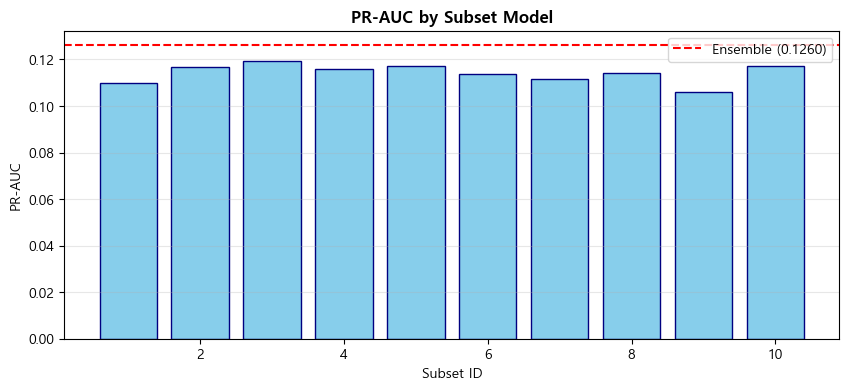

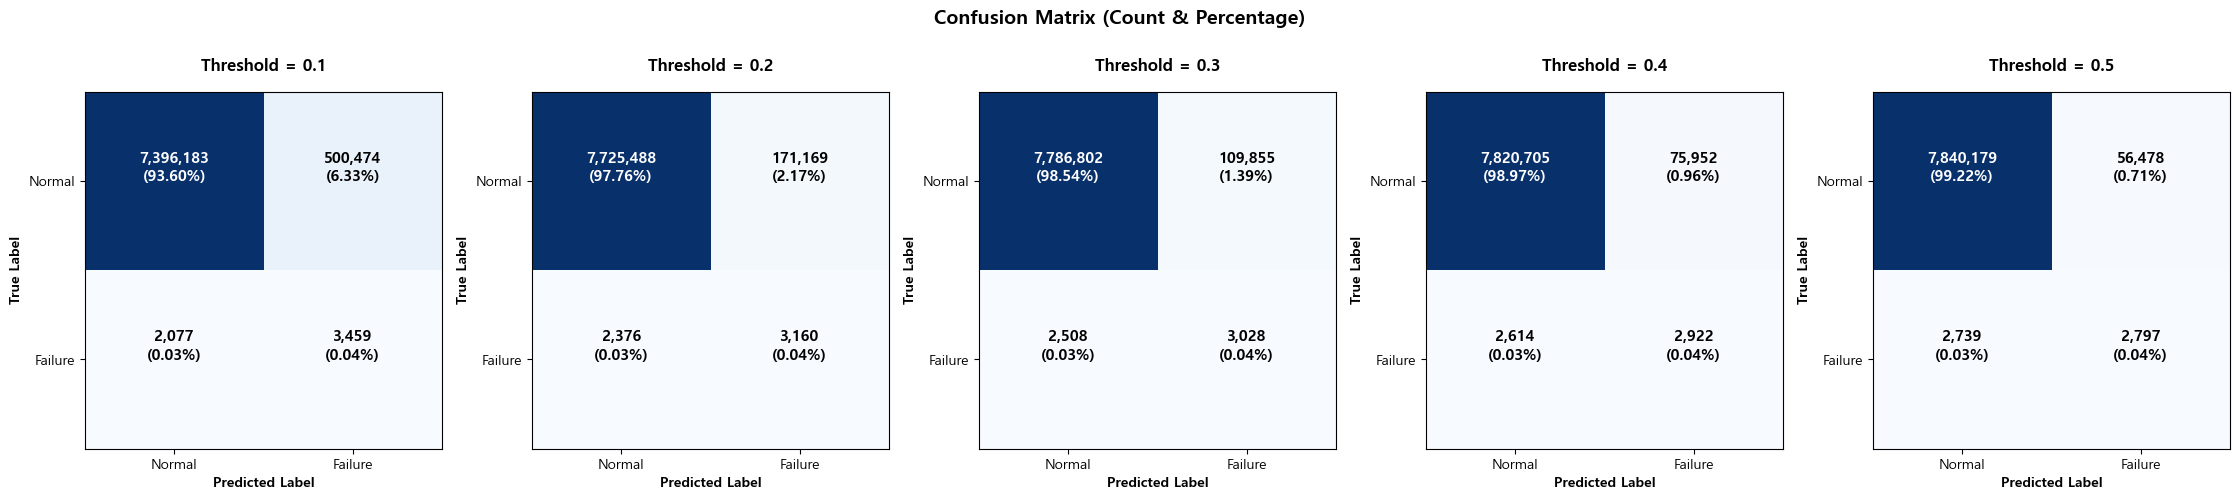

In [ ]:
print('\n=========================================')
print('Selected best hyperparameters')
print('=========================================')
for k, v in best_params.items():
    print(f'  - {k}: {v}')

print_ensemble_summary(ens_result)
plot_subset_prauc(ens_result)
plot_confusion_matrix(ens_result, cfg)


## 4. 최종 모델 및 설정 저장

In [ ]:
import joblib, json
from pathlib import Path

SAVE_DIR = Path(cfg.MODEL_SAVE_DIR)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 서브셋 모델 저장
for i, model in enumerate(ens_result.models):
    path = SAVE_DIR / f'subset_{i:02d}.pkl'
    joblib.dump(model, path)
    print(f'  저장: {path}')

# 피처 목록 저장
feat_path = SAVE_DIR / 'feature_cols.json'
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(result_dict['feature_cols'], f, ensure_ascii=False, indent=2)
print(f'  피처 목록: {feat_path}')

# best_params 저장
param_path = SAVE_DIR / 'best_params.json'
with open(param_path, 'w', encoding='utf-8') as f:
    json.dump(best_params, f, ensure_ascii=False, indent=2)
print(f'  파라미터 : {param_path}')

  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_00.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_01.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_02.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_03.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_04.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_05.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_06.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_07.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_08.pkl
  저장: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\subset_09.pkl
  피처 목록: c:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble\feature_cols.json
  파라미터 : c:\Workspace\06_ML_projdect